# Statistical Inference on Walmart Purchase Data: A Gender and Demographic Study

### About Walmart
Walmart is an American multinational retail corporation that operates a chain of supercenters, discount departmental stores, and grocery stores from the United States. Walmart has more than 100 million customers worldwide.

### Business Problem
The Management team at Walmart Inc. wants to analyze the customer purchase behavior (specifically, purchase amount) against the customer’s gender and the various other factors to help the business make better decisions. They want to understand if the spending habits differ between male and female customers: Do women spend more on Black Friday than men? (Assume 50 million customers are male and 50 million are female).

### Core questions this EDA answers
1. What is the overall purchase/spend mix?
2. Do men and women spend differently? (mean, median, CLT confidence intervals)
3. Does marital status affect spend?
4. Which age groups are the most valuable?
5. Which city categories and product categories drive revenue?
6. What is the probability of a high-value purchase for each segment?
7. How can Walmart use confidence intervals to size marketing budgets?

### Dataset
The company collected the transactional data of customers who purchased products from the Walmart Stores during Black Friday. The dataset has the following features:

Dataset link: https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/293/original/walmart_data.csv?1641285094

* User_ID:  User ID
* Product_ID: Product ID
* Gender: Sex of User
* Age:  Age in bins
* Occupation: Occupation(Masked)
* City_Category:  Category of the City (A,B,C)
* Stay_In_Current_City_Years: Number of years stay in current city
* Marital_Status: Marital Status (0 = Unmarried, 1 = Married)
* ProductCategory:  Product Category (Masked)
* Purchase: Purchase Amount

### Disclaimer
This analysis is based on the data provided and reflects the state of the dataset as of the time of the analysis. The insights and recommendations are derived solely from my point of view and the dataset in question do not necessarily represent the broader operations or circumstances of the company. The analysis assumes the accuracy of the data as received and has not been independently verified. Future analyses may yield different insights as new data becomes available or as business conditions change.

### Note on Results
Due to the large volume of results generated by this analysis, only a subset has been presented here to illustrate the key trends and patterns. For a complete view of the data and to explore additional insights, please refer to the full dataset.

## ANALYSIS SETUP

In [2]:
%pip install --quiet pandas numpy matplotlib seaborn scipy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore') # ignore all warnings

Note: you may need to restart the kernel to use updated packages.


## OBSERVE DATASET

Downloading...
From: https://drive.google.com/uc?id=10MSSbDR26XJCPCKXWMWq-YANpzCepCX0
To: /Users/hithesh/Documents/GitHub/Confidence-Interval-CLT/walmart_data.csv
100%|██████████████████████████████████████| 23.0M/23.0M [00:00<00:00, 26.0MB/s]
Data Downloaded





,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


Data Loaded



SHAPE:
(550068, 10)



MISSING VALUES PER COL:
User_ID                       0
Product_ID                    0
Gender                        0
Age                           0
Occupation                    0
City_Category                 0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category              0
Purchase                      0
dtype: int64



MISSING VALUES TOTAL:
0



DUPLICATE COUNT:
0



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     550068 non-null  int64 
 1   Product_ID                  550068 non-null  object
 2   Gender                      550068 non-null  object
 3   Age                         550068 non-null  object
 4   Occupation                  550068 non-null  int64 
 5   City_Category               550068 non

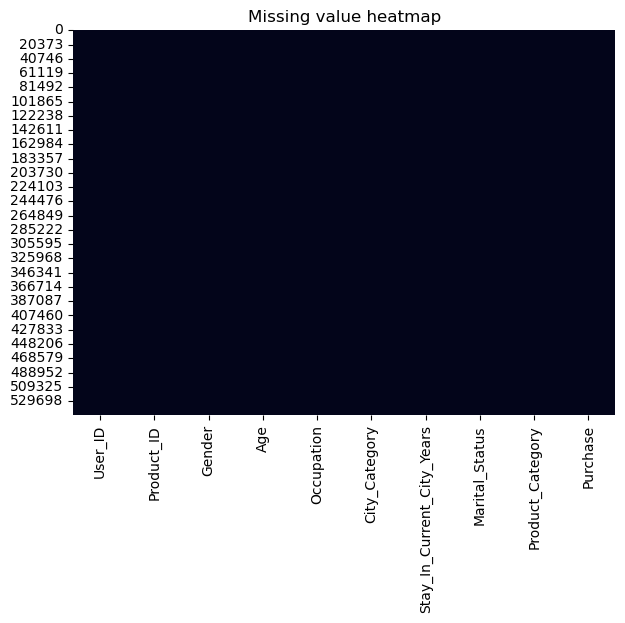

In [3]:
!gdown 10MSSbDR26XJCPCKXWMWq-YANpzCepCX0
print(f"Data Downloaded\n\n\n")

df = pd.read_csv('walmart_data.csv')
display(df.head())
print(f"Data Loaded\n\n\n")

print(f"SHAPE:\n{df.shape}\n\n\n")
print(f"MISSING VALUES PER COL:\n{df.isnull().sum()}\n\n\n")
print(f"MISSING VALUES TOTAL:\n{df.isnull().sum().sum()}\n\n\n")
print(f"DUPLICATE COUNT:\n{df.duplicated().sum()}\n\n\n")
print(f"INFO:\n{df.info()}\n\n\n")

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(data=df.isnull(), cbar=False, ax=ax)
ax.set_title("Missing value heatmap")
plt.show()


## CLEAN & OPTIMISE DATA

In [4]:
# Convert repetitive strings to category for memory and speed
cat_cols = list(df.select_dtypes(include=["object"]).columns)
cat_cols.extend(["Marital_Status", "Product_Category", "Occupation"])
for col in cat_cols:
  df[col] = df[col].astype("category")

df.info()

print('\nConclusion')
print('Is dataset explorable? Yes')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype   
---  ------                      --------------   -----   
 0   User_ID                     550068 non-null  int64   
 1   Product_ID                  550068 non-null  category
 2   Gender                      550068 non-null  category
 3   Age                         550068 non-null  category
 4   Occupation                  550068 non-null  category
 5   City_Category               550068 non-null  category
 6   Stay_In_Current_City_Years  550068 non-null  category
 7   Marital_Status              550068 non-null  category
 8   Product_Category            550068 non-null  category
 9   Purchase                    550068 non-null  int64   
dtypes: category(8), int64(2)
memory usage: 13.3 MB

Conclusion
Is dataset explorable? Yes


## CHARACTERISTICS OF TARGET VARIABLE


ROW GRANULARITY:
A single row represents an item transaction, not an individual customer. 
Because one customer (User_ID) can have multiple rows (purchases across different product categories). 






A TARGET VARIABLE FOR ANALYSING CUSTOMER SPENDING HABITS:
Purchase 






TARGET VARIABLE PREDICTORS (Independent/Feature variables):
Gender, Marital_Status, Age, City_Category, and ProductCategory







count                550068.00
mean                   9263.97
std                    5023.07
min                      12.00
25%                    5823.00
50%                    8047.00
75%                   12054.00
max                   23961.00
median                 8047.00
mean_minus_median      1216.97
range                 23949.00
IQR                    6231.00
Name: Purchase, dtype: float64

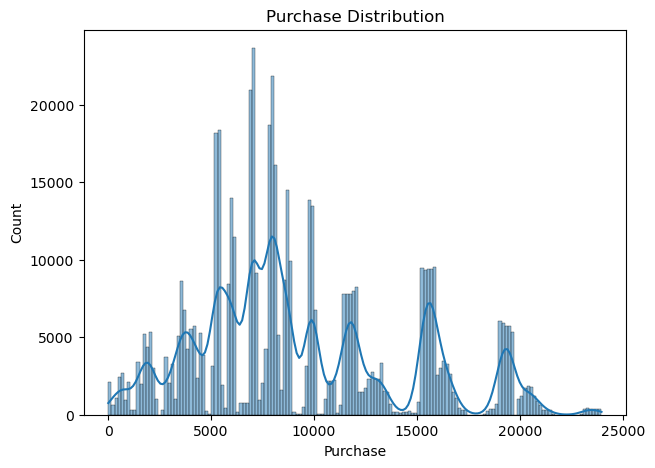






SHAPE OF DISTRUIBUTION:
Right Skewed and Multimodal.
The bulk of the transactions are concentrated on the lower-to-middle end (under $10,000).
The distribution extends out with a longer tail to the right toward higher transaction values (reaching up to $20,000+).






MODALITY:
The Purchase variable is multimodal (it has multiple distinct spikes/peaks around $5,000, $8,000, $12,000, $16,000, and $19,000). 
This happens because items fall into fixed price tiers or specific product categories.







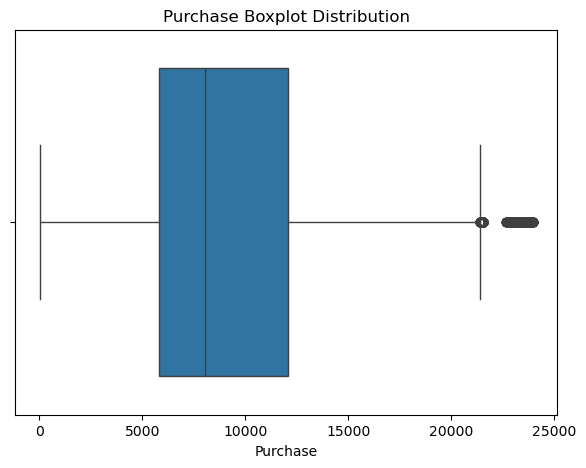






STANDARD LOWER OUTLIERS:
0






STANDARD UPPER OUTLIERS:
2677






EXTREME LOWER OUTLIERS:
0






EXTREME UPPER OUTLIERS:
0







In [5]:

print(f"""
ROW GRANULARITY:
A single row represents an item transaction, not an individual customer. 
Because one customer (User_ID) can have multiple rows (purchases across different product categories). 
\n\n\n
""")

print(f"""
A TARGET VARIABLE FOR ANALYSING CUSTOMER SPENDING HABITS:
'Purchase' Column 
\n\n\n
""")

print(f"""
TARGET VARIABLE PREDICTORS (Independent/Feature variables):
Gender, Marital_Status, Age, City_Category, and ProductCategory
\n\n\n
""")

df_target = df["Purchase"].describe().T
df_target["median"] = df["Purchase"].median()
df_target["mean_minus_median"] = df["Purchase"].mean() - df["Purchase"].median()
df_target["range"] = df["Purchase"].max() - df["Purchase"].min()
df_target["IQR"] = df_target.loc["75%"] - df_target.loc["25%"]
display(round(df_target, 2))

print("\n\n\n")

fig, ax = plt.subplots(figsize=(7, 5))
sns.histplot(data=df["Purchase"], kde=True, ax=ax)
ax.set_title("Purchase Distribution")
plt.show()

print("\n\n\n")

print(f"""
SHAPE OF DISTRUIBUTION:
Right Skewed and Multimodal.
The bulk of the transactions are concentrated on the lower-to-middle end (under $10,000).
The distribution extends out with a longer tail to the right toward higher transaction values (reaching up to $25,000).
\n\n\n
""")


print(f"""
MODALITY:
The Purchase variable is multimodal (it has multiple distinct spikes/peaks around $5,000, $8,000, $12,000, $16,000, and $19,000). 
This happens because items fall into fixed price tiers or specific product categories.
\n\n\n
""")



fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df["Purchase"], orient="h", ax=ax)
ax.set_title("Purchase Boxplot Distribution")
plt.show()


print("\n\n\n")


# Since distribution is not normal we will ignore X Score > 3 and use IQR insted.
q3 = df_target.loc["75%"]
q1 = df_target.loc["25%"]
std_lower = q1 - (1.5*df_target.loc["IQR"])
std_upper = q3 + (1.5*df_target.loc["IQR"])
ext_lower = q1 - (3*df_target.loc["IQR"])
ext_upper = q3 + (3*df_target.loc["IQR"])
std_lower_outliers = df[df["Purchase"] < std_lower]
std_upper_outliers = df[df["Purchase"] > std_upper]
ext_lower_outliers = df[df["Purchase"] < ext_lower]
ext_upper_outliers = df[df["Purchase"] > ext_upper]
print(f"""
STANDARD LOWER OUTLIERS:
{len(std_lower_outliers)}
\n\n\n
""")
print(f"""
STANDARD UPPER OUTLIERS:
{len(std_upper_outliers)}
\n\n\n
""")
print(f"""
EXTREME LOWER OUTLIERS:
{len(ext_lower_outliers)}
\n\n\n
""")
print(f"""
EXTREME UPPER OUTLIERS:
{len(ext_upper_outliers)}
\n\n\n
""")

## DESCRIPTIVE STATS

In [6]:
print(f"SUMMARY OF CATEGORICAL VARS:------------ \n{df.describe(include=['object', 'category'])}\n\n\n")

numeric_cols = [c for c in df.select_dtypes(include=['number']).columns if c != 'User_ID']
df_stats = df[numeric_cols].describe().T
df_stats['median'] = df[numeric_cols].median()
df_stats['mean_minus_median'] = df[numeric_cols].mean() - df[numeric_cols].median()
print(f"SUMMARY OF NUMERICAL VARS:------------ \n{df_stats.round(2)}\n\n\n")

print(f"UNIQUE VALUES PER COL:------------ \n{df.nunique()}")

SUMMARY OF CATEGORICAL VARS:------------ 
       Product_ID  Gender     Age  Occupation City_Category  \
count      550068  550068  550068      550068        550068   
unique       3631       2       7          21             3   
top     P00265242       M   26-35           4             B   
freq         1880  414259  219587       72308        231173   

       Stay_In_Current_City_Years  Marital_Status  Product_Category  
count                      550068          550068            550068  
unique                          5               2                20  
top                             1               0                 5  
freq                       193821          324731            150933  



SUMMARY OF NUMERICAL VARS:------------ 
             count     mean      std   min     25%     50%      75%      max  \
Purchase  550068.0  9263.97  5023.07  12.0  5823.0  8047.0  12054.0  23961.0   

          median  mean_minus_median  
Purchase  8047.0            1216.97  



UNIQUE VA

## OUTLIER DETECTION (IQR)


Purchase outliers by Gender:
Gender
M    2088
F     589
Name: count, dtype: int64

IQR outlier summary:
   Variable  IQR_Lower  IQR_Upper  Outliers_Count
0  Purchase    -3523.5    21400.5            2677


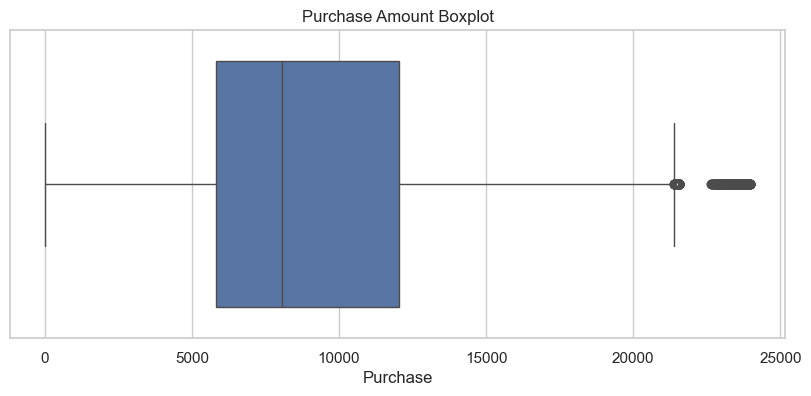

In [20]:
def iqr_outlier_info(s: pd.Series):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers_mask = (s < lower) | (s > upper)
    return lower, upper, outliers_mask

outlier_rows = []
for col in ['Purchase']:
    lower, upper, outliers_mask = iqr_outlier_info(df[col])
    outlier_rows.append([col, lower, upper, int(outliers_mask.sum())])
    print(f"\n{col} outliers by Gender:")
    print(df.loc[outliers_mask, 'Gender'].value_counts())

outlier_df = pd.DataFrame(outlier_rows, columns=['Variable', 'IQR_Lower', 'IQR_Upper', 'Outliers_Count'])
print('\nIQR outlier summary:')
print(outlier_df)

fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(x=df['Purchase'], ax=ax)
ax.set_title('Purchase Amount Boxplot')
plt.show()

## MONEY LENS (REVENUE PROXY)

In [24]:
# Imp cols - Gender, Age, Marital Status, City Category, Product Category (Top 10)
cat_cols = df.select_dtypes(include=["category"])

def money_segment(col: str):
    return df.groupby(col, observed=False).agg(
                            total_transactions=("Purchase", "count"),
                            unique_customers=("User_ID", "nunique"),
                            AOV=("Purchase", "mean"),
                            revenue=("Purchase", "sum"),
                            revenue_share=("Purchase", lambda x : x.sum()/df["Purchase"].sum())
                        ).sort_values("revenue", ascending=False)

for col in cat_cols:
    print(f"{col} Top 10 Money Lens".upper())
    
    display(
      round(money_segment(col).head(10), 4)
    )
    
    print("\n\n\n")

PRODUCT_ID TOP 10 MONEY LENS


,total_transactions,unique_customers,AOV,revenue,revenue_share
Product_ID,,,,,
P00025442,1615,1615,17334.4681,27995166,0.0055
P00110742,1612,1612,16577.1148,26722309,0.0052
P00255842,1383,1383,18198.8163,25168963,0.0049
P00059442,1406,1406,17310.3435,24338343,0.0048
P00184942,1440,1440,16899.2271,24334887,0.0048
P00112142,1562,1562,15503.2049,24216006,0.0048
P00110942,1360,1360,17382.0324,23639564,0.0046
P00237542,1394,1394,16804.5739,23425576,0.0046
P00057642,1470,1470,15716.1769,23102780,0.0045






GENDER TOP 10 MONEY LENS


,total_transactions,unique_customers,AOV,revenue,revenue_share
Gender,,,,,
M,414259,4225,9437.5260,3909580100,0.7672
F,135809,1666,8734.5658,1186232642,0.2328






AGE TOP 10 MONEY LENS


...

,total_transactions,unique_customers,AOV,revenue,revenue_share
Marital_Status,,,,,
0,324731,3417,9265.9076,3008927447,0.5905
1,225337,2474,9261.1746,2086885295,0.4095






PRODUCT_CATEGORY TOP 10 MONEY LENS


,total_transactions,unique_customers,AOV,revenue,revenue_share
Product_Category,,,,,
1,140378,5767,13606.2186,1910013754,0.3748
5,150933,5751,6240.0882,941835229,0.1848
8,113925,5659,7498.9581,854318799,0.1677
6,20466,4085,15838.4785,324150302,0.0636
2,23864,4296,11251.9354,268516186,0.0527
3,20213,3838,10096.7057,204084713,0.0400
16,9828,3130,14766.0370,145120612,0.0285
11,24287,3583,4685.2685,113791115,0.0223
10,5125,2328,19675.5709,100837301,0.0198






SPENDTIER TOP 10 MONEY LENS


,total_transactions,unique_customers,AOV,revenue,revenue_share
SpendTier,,,,,
premium,137479,5821,16509.8923,2269763482,0.4454
high,137447,5858,9851.6818,1354084115,0.2657
medium,137595,5808,7062.8363,971810959,0.1907
low,137547,5837,3636.2421,500154186,0.0982


## PROBABILITIES (CONTINGENCY TABLE)

In [27]:
# Figure out how a particular predictor variable is influencing spending behaviour
def calc_prob(col1: str, col2: str):
    ct = pd.crosstab(index=df[col1], columns=df[col2])
    
    joint = ct / ct.values.sum()
    
    row_marg = joint.sum(axis=1) # P(row)
    col_marg = joint.sum(axis=0) # P(col)
    
    p_row_given_col = joint.div(col_marg, axis=1) # P(row | col)
    p_col_given_row = joint.div(row_marg, axis=0) # P(col | row)
    
    # Chi-Square Test of Independence
    chi2, p_val, dof, _ = stats.chi2_contingency(ct)
    
    return ct.round(3), joint.round(3), row_marg.round(3), col_marg.round(3), p_row_given_col.round(3), p_col_given_row.round(3), chi2, p_val, dof

# Build a spend tier to turn purchase into a categorical decision variable
df["SpendTier"] = pd.qcut(x=df["Purchase"], q=4, labels=["low", "medium", "high", "premium"])

p_row_given_col_map = {}
cat_cols = ['Gender', 'Marital_Status', 'Age', 'City_Category']
for col in cat_cols:
    ct, joint, row_marg, col_marg, p_row_given_col, p_col_given_row, chi2, p_val, dof = calc_prob(col1="SpendTier", col2=col)
    p_row_given_col_map[col] = p_row_given_col
    
    print(f"Contingency : SpendTier x {col}:\n{ct}\n")
    
    print(f"Marginal Probabilities:\n{col_marg}\n")
    
    print(f"--- CHI-SQUARE TEST OF INDEPENDENCE (SpendTier vs {col}) ---")
    print(f"Chi2: {chi2:.2f}, p-value: {p_val:.4e}, dof: {dof}")
    
    if p_val < 0.05:
      print(f"Result: Reject H0 — Significant association between SpendTier and {col}.")
    else:
      print(f"Result: Fail to reject H0 — No significant association between SpendTier and {col}.")

    # To find out the direction of influence u must check conditionals. Ex: If Gender influences SpendTier. Chi2 only tells us magnitude of association.
    print(f"SpendTier | {col}:\n{p_row_given_col}\n")
    print(f"{col} | SpendTier:\n{p_col_given_row}\n")
    
    print("\n\n\n")

    

Contingency : SpendTier x Gender:
Gender         F       M
SpendTier               
low        35967  101580
medium     37266  100329
high       34677  102770
premium    27899  109580

SpendTier | Gender:
Gender         F      M
SpendTier              
low        0.265  0.245
medium     0.274  0.242
high       0.255  0.248
premium    0.205  0.265

Gender | SpendTier:
Gender         F      M
SpendTier              
low        0.261  0.739
medium     0.271  0.729
high       0.252  0.748
premium    0.203  0.797

Marginal Probabilities:
Gender
F    0.247
M    0.753
dtype: float64

--- CHI-SQUARE TEST OF INDEPENDENCE (SpendTier vs Gender) ---
Chi2: 2032.31, p-value: 0.0000e+00, dof: 3
Result: Reject H0 — Significant association between SpendTier and Gender.




Contingency : SpendTier x Marital_Status:
Marital_Status      0      1
SpendTier                   
low             81828  55719
medium          80848  56747
high            80654  56793
premium         81401  56078

SpendTier | Mari

## CLT & CONFIDENCE INTERVALS
Exploratory Phase. What does the overall data spread look like?

Overall observed AOV
Female: ₹8734.57
Male:   ₹9437.53
Difference: ₹702.96
CLT demonstration: sample size effect on distribution of means


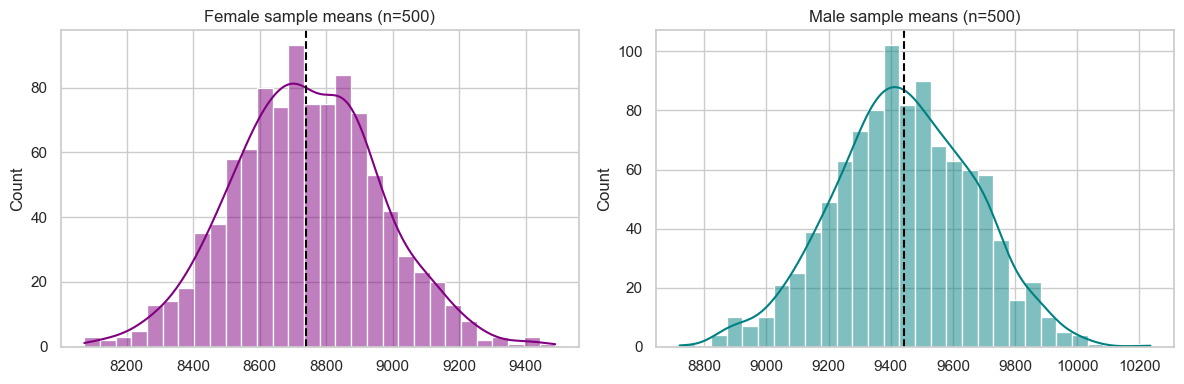

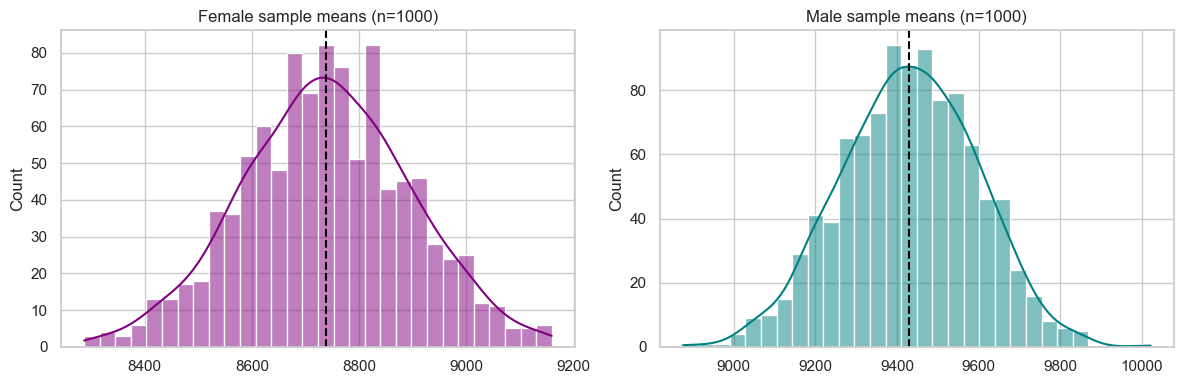

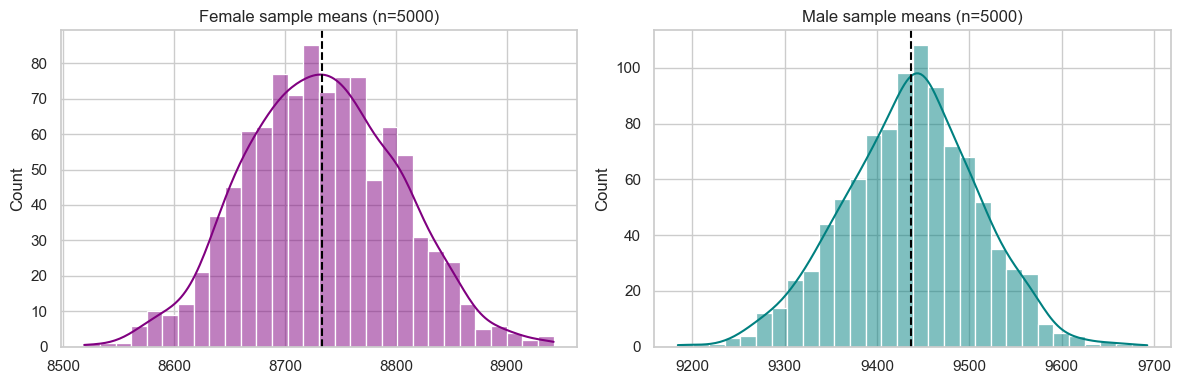

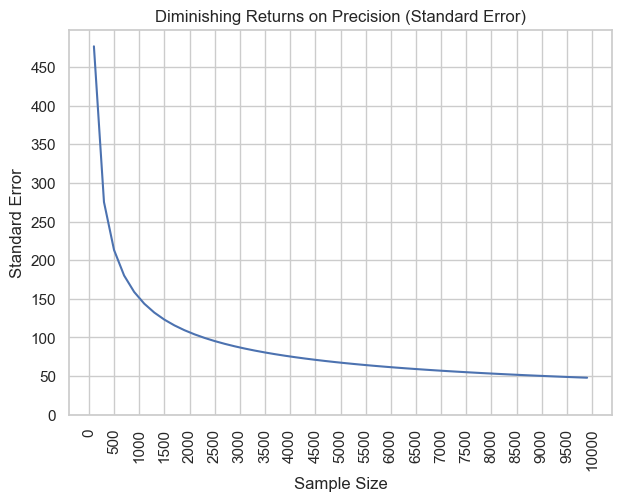


    We are choosing [500, 1000, 5000] sample size because doubling the sample size 
    reduces the standard error by a factor of 1.4 which is tiny beyond 5000 items 
    as seen in graph. Because SE value is already small at this point, 
    dividing a small number further gives us diminishing returns. 
    That is "Law of Diminishing returns".
    




Confidence intervals for mean purchase by gender


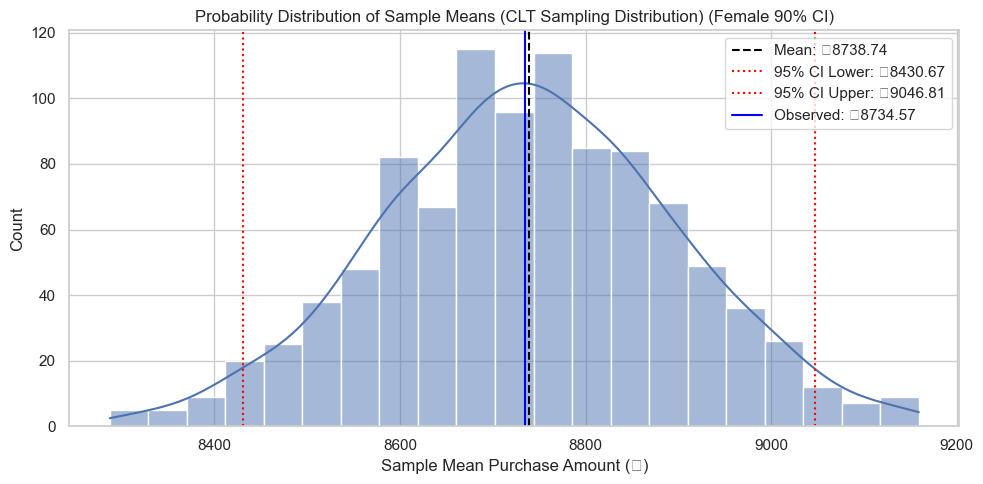

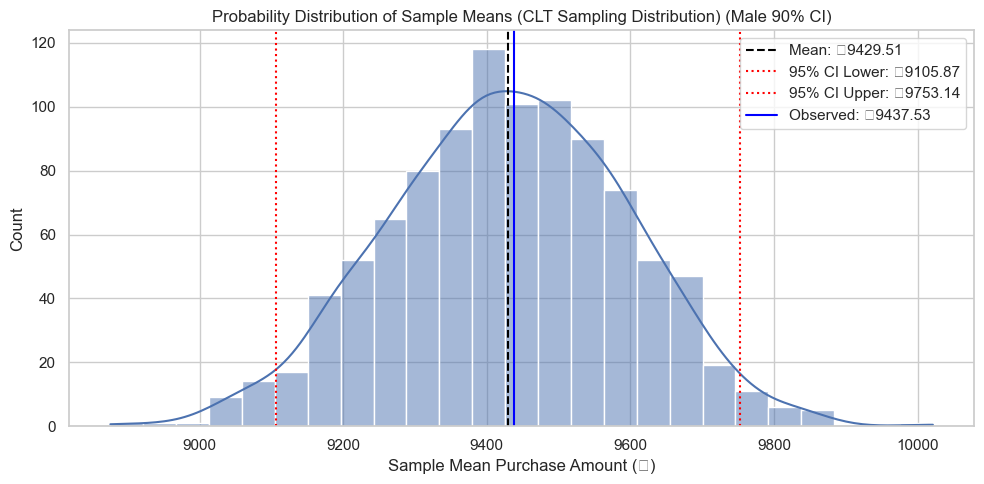

90% CI:
  Female: ₹8477 - ₹8999  (mean ₹8739)
  Male:   ₹9165 - ₹9692  (mean ₹9430)
  CIs overlap? False






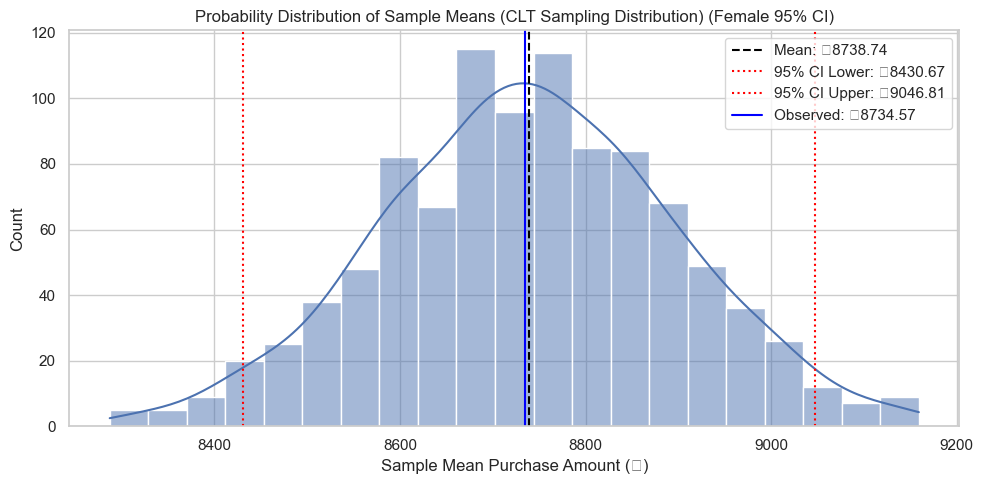

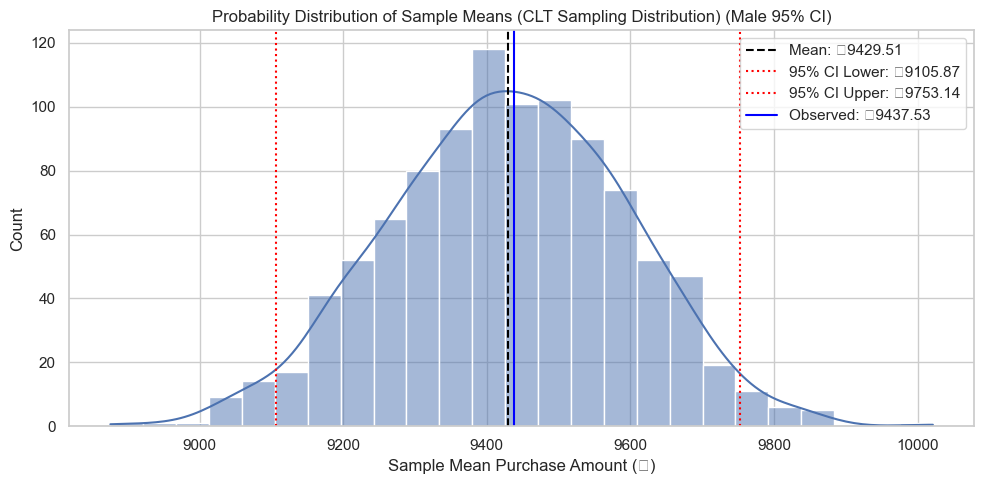

95% CI:
  Female: ₹8429 - ₹9050  (mean ₹8739)
  Male:   ₹9105 - ₹9740  (mean ₹9430)
  CIs overlap? False






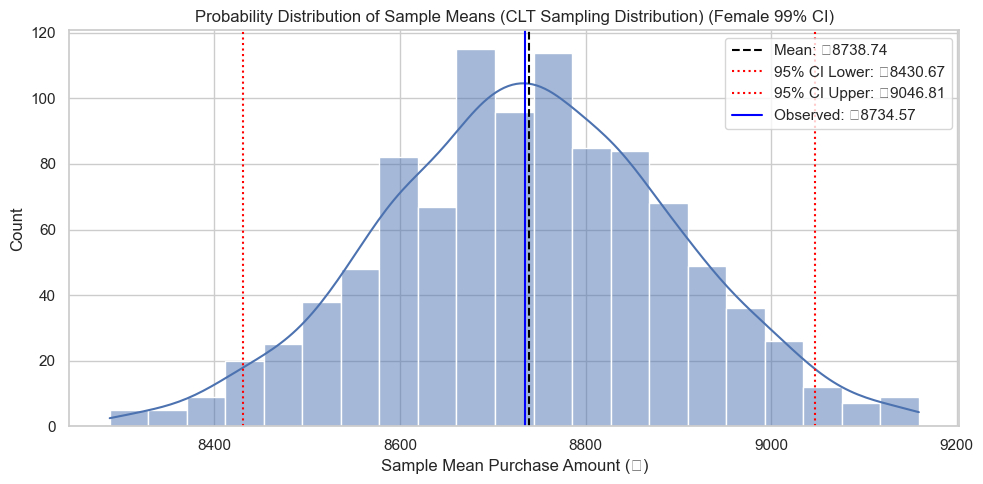

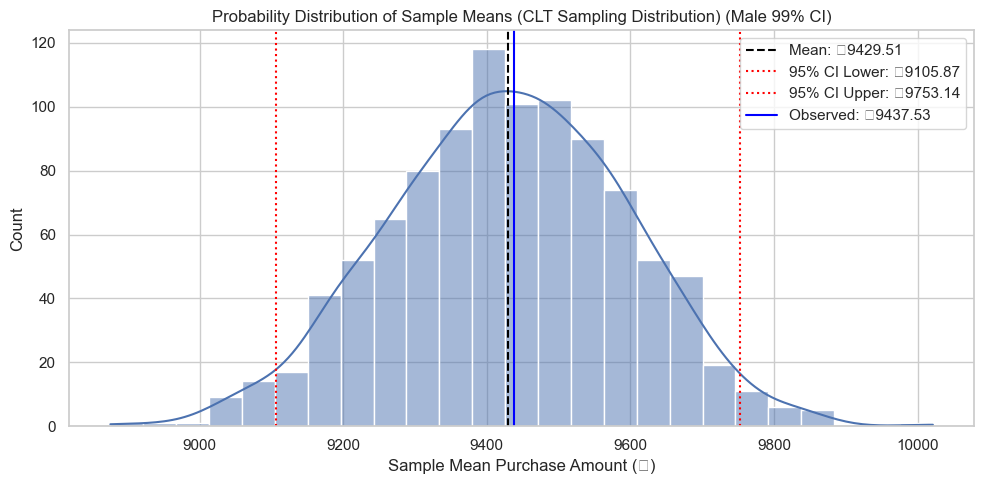

99% CI:
  Female: ₹8329 - ₹9141  (mean ₹8739)
  Male:   ₹9021 - ₹9841  (mean ₹9430)
  CIs overlap? True








Marital Status comparison


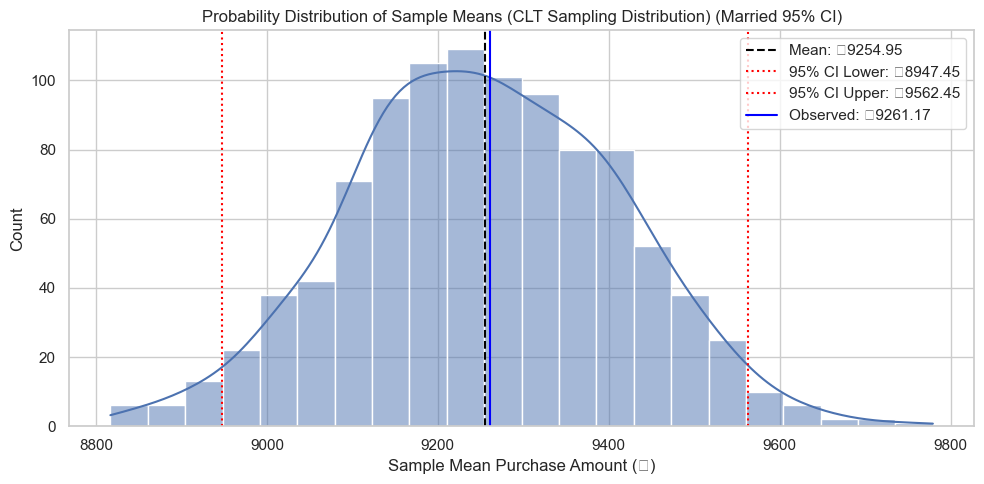

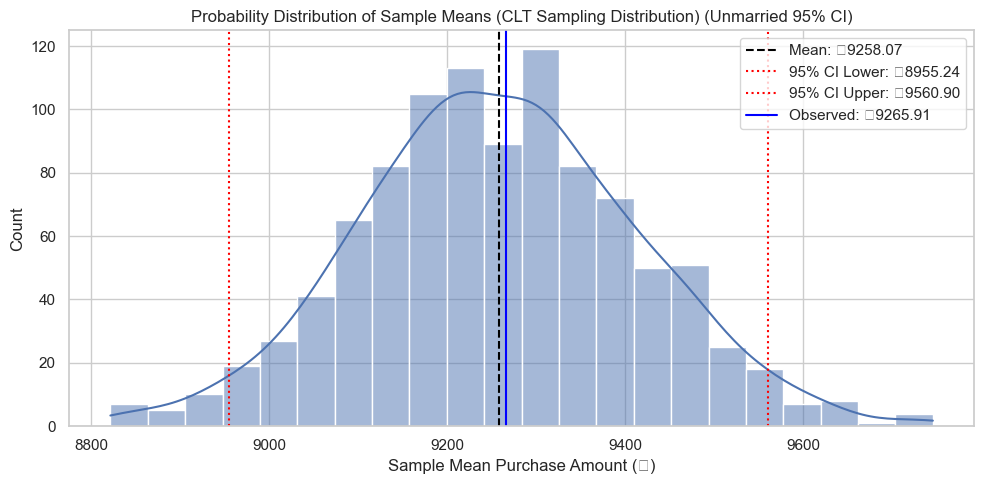

95% CI:
  Married:   ₹8949 - ₹9553  (mean ₹9255)
  Unmarried: ₹8954 - ₹9561  (mean ₹9258)




Age group comparison (95% CI, ordered by AOV)
  0-17: ₹8629 - ₹9246 (mean ₹8932)
  18-25: ₹8850 - ₹9481 (mean ₹9173)
  26-35: ₹8950 - ₹9566 (mean ₹9259)
  36-45: ₹9011 - ₹9639 (mean ₹9325)
  46-50: ₹8897 - ₹9516 (mean ₹9209)
  51-55: ₹9211 - ₹9842 (mean ₹9533)
  55+: ₹9015 - ₹9650 (mean ₹9337)


In [52]:
"""
We use confidence intervals to compare the average spending of men and women because
they give us a reliable range for where the true population average lies. 
When those intervals don't overlap, it provides strong evidence that the 
difference in spending habits between the two groups is statistically significant, 
helping to answer the business question directly.

Probabilities and point estimates, like sample means or conditional proportions, 
tell us about the frequencies or the average within our specific sample, 
but they don't give us a precise range for the larger population. 
Confidence intervals, on the other hand, calculated using the Central Limit Theorem, 
give us a range of values where we can be confident the true population parameter lies. 
This allows us to see if there's a statistically significant difference between groups, 
which is incredibly helpful for decision-making.

If confidence intervals do not overlap at all, 
you can safely and strongly conclude they are statistically significantly different.
If they do overlap slightly, it doesn't automatically mean they aren't different, 
it just means the visual test is inconclusive, 
and you need to rely on a formal t-test or z-test to get the precise p-value.
"""

def clt_sample_means(data, sample_size=1000, n_samples=1000):
    np.random.seed(42)
    # Bootstrap simulation for CLT demonstration.
    # Ensure sample size doesn't exceed dataset length if using replace=False, or keep replace=True
    # We do mean along axis=1 because each row is a sample, even though data set is 1D Purchase col
    return np.random.choice(data, size=(n_samples, sample_size), replace=True).mean(axis=1) 
    
def ci_of_means(means, confidence=0.95):
    # Quantile-based empirical CI for bootstrapped distribution
    alpha = (1 - confidence) / 2 # Divide by 2 because the interval is the middle part of the distribution
    low, high = np.percentile(means, [alpha * 100, (1 - alpha) * 100])
    se = np.std(means, ddof=1)
    return means.mean(), low, high, se, means

def show_ci_plot(clt_samples, mu, se, observed_val=None, side="two-sided", title_suffix=""):
    # Plots CLT distribution against sample observations with directional critical thresholds.
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.histplot(data=clt_samples, kde=True, ax=ax)
    
    ax.axvline(mu, color="black", linestyle="--", label=f"Mean: ₹{mu:.2f}")
    
    if side == "left":
        threshold = mu + (stats.norm.ppf(0.05) * se)
        ax.axvline(threshold, color="red", linestyle=":", label=f"5% Left Threshold: ₹{threshold:.2f}")
    elif side == "right":
        threshold = mu + (stats.norm.ppf(0.95) * se)
        ax.axvline(threshold, color="red", linestyle=":", label=f"5% Right Threshold: ₹{threshold:.2f}")
    elif side == "two-sided":
        low_th = mu + (stats.norm.ppf(0.025) * se)
        high_th = mu + (stats.norm.ppf(0.975) * se)
        ax.axvline(low_th, color="red", linestyle=":", label=f"95% CI Lower: ₹{low_th:.2f}")
        ax.axvline(high_th, color="red", linestyle=":", label=f"95% CI Upper: ₹{high_th:.2f}")
    
    if observed_val is not None:
        ax.axvline(observed_val, color="blue", label=f"Observed: ₹{observed_val:.2f}")
        
    ax.set_title(f"Probability Distribution of Sample Means (CLT Sampling Distribution) ({title_suffix})")
    plt.xlabel("Sample Mean Purchase Amount (₹)")
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

def show_samplesize_graph():
    sample_sizes = range(100, 10000, 200)
    standard_errors = [female.std() / np.sqrt(n) for n in sample_sizes]
    
    # Plotting sample size vs standard error to visually spot the "elbow" curve
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.lineplot(x=sample_sizes, y=standard_errors, ax=ax)
    ax.set_title("Diminishing Returns on Precision (Standard Error)")
    
    plt.xticks(range(0, 10500, 500))
    plt.yticks(range(0, 500, 50))
    plt.xticks(rotation=90)
    plt.xlabel("Sample Size")
    plt.ylabel("Standard Error")
    plt.show()
    
    print(f"""
    We are choosing [500, 1000, 5000] sample size because doubling the sample size 
    reduces the standard error by a factor of 1.4 which is tiny beyond 5000 items 
    as seen in graph. Because SE value is already small at this point, 
    dividing a small number further gives us diminishing returns. 
    That is "Law of Diminishing returns".
    """)


# Analysis Execution

female = df[df['Gender'] == 'F']['Purchase'].values
male = df[df['Gender'] == 'M']['Purchase'].values

print('Overall observed AOV')
print(f'Female: ₹{female.mean():.2f}')
print(f'Male:   ₹{male.mean():.2f}')
print(f'Difference: ₹{male.mean() - female.mean():.2f}')

print('CLT demonstration: sample size effect on distribution of means')
for ssize in [500, 1000, 5000]:
    f_means = clt_sample_means(female, sample_size=ssize, n_samples=1000)
    m_means = clt_sample_means(male, sample_size=ssize, n_samples=1000)
    
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    
    sns.histplot(f_means, kde=True, bins=30, ax=ax[0], color="purple")
    ax[0].axvline(f_means.mean(), color="black", linestyle="--")
    ax[0].set_title(f'Female sample means (n={ssize})')
    
    sns.histplot(m_means, kde=True, bins=30, ax=ax[1], color="teal")
    ax[1].axvline(m_means.mean(), color="black", linestyle="--")
    ax[1].set_title(f'Male sample means (n={ssize})')
    
    plt.tight_layout()
    plt.show()
    print("\n\n\n")
    
show_samplesize_graph()
print("\n\n\n")

print('Confidence intervals for mean purchase by gender')
for level in [0.90, 0.95, 0.99]:
    f_samp_means = clt_sample_means(female, 1000, 1000)
    m_samp_means = clt_sample_means(male, 1000, 1000)
    
    f_mean, f_low, f_high, f_se, f_means_list = ci_of_means(f_samp_means, level)
    m_mean, m_low, m_high, m_se, m_means_list = ci_of_means(m_samp_means, level)
    
    overlap = not (f_high < m_low or m_high < f_low)
    
    show_ci_plot(f_means_list, f_mean, f_se, female.mean(), side="two-sided", title_suffix=f"Female {int(level*100)}% CI")
    show_ci_plot(m_means_list, m_mean, m_se, male.mean(), side="two-sided", title_suffix=f"Male {int(level*100)}% CI")
    
    print(f"{int(level*100)}% CI:")
    print(f"  Female: ₹{f_low:.0f} - ₹{f_high:.0f}  (mean ₹{f_mean:.0f})")
    print(f"  Male:   ₹{m_low:.0f} - ₹{m_high:.0f}  (mean ₹{m_mean:.0f})")
    print(f"  CIs overlap? {overlap}")
    print("\n\n\n")

print("\n\n\n")
print('Marital Status comparison')
married = df[df['Marital_Status'] == 1]['Purchase'].values
unmarried = df[df['Marital_Status'] == 0]['Purchase'].values

for level in [0.95]:
    m_samp_means = clt_sample_means(married, 1000, 1000)
    um_samp_means = clt_sample_means(unmarried, 1000, 1000)
    
    m_mean, ml, mh, m_se, m_means_list = ci_of_means(m_samp_means, level)
    um_mean, uml, umh, um_se, um_means_list = ci_of_means(um_samp_means, level)
    
    show_ci_plot(m_means_list, m_mean, m_se, married.mean(), side="two-sided", title_suffix="Married 95% CI")
    show_ci_plot(um_means_list, um_mean, um_se, unmarried.mean(), side="two-sided", title_suffix="Unmarried 95% CI")
    
    print(f"{int(level*100)}% CI:")
    print(f"  Married:   ₹{ml:.0f} - ₹{mh:.0f}  (mean ₹{m_mean:.0f})")
    print(f"  Unmarried: ₹{uml:.0f} - ₹{umh:.0f}  (mean ₹{um_mean:.0f})")

print("\n\n\n")
print('Age group comparison (95% CI, ordered by AOV)')
age_order = np.sort(df["Age"].unique())

for level in [0.95]:
    for age in age_order:
        age_data = df[df['Age'] == age]['Purchase'].values
        
        age_samp_means = clt_sample_means(age_data, 1000, 1000)
        
        am, al, ah, _, _ = ci_of_means(age_samp_means, level)
        
        print(f"  {age}: ₹{al:.0f} - ₹{ah:.0f} (mean ₹{am:.0f})")



## HYPOTHESIS TESTS
Detection Phase. Is there a real difference somewhere in this data?

--- OVERALL OBSERVED METRICS ---
Female Mean: ₹8734.57
Male Mean:   ₹9437.53
Difference:  ₹702.96
--- PARAMETRIC CONFIDENCE INTERVALS (GENDER) ---
90% Confidence Interval:
  Female: ₹8713.29 - ₹8755.84  (SE: ₹12.94)
  Male:   ₹9424.51 - ₹9450.54  (SE: ₹7.91)
  CIs Overlap? False
95% Confidence Interval:
  Female: ₹8709.21 - ₹8759.92  (SE: ₹12.94)
  Male:   ₹9422.02 - ₹9453.03  (SE: ₹7.91)
  CIs Overlap? False
99% Confidence Interval:
  Female: ₹8701.24 - ₹8767.89  (SE: ₹12.94)
  Male:   ₹9417.15 - ₹9457.91  (SE: ₹7.91)
  CIs Overlap? False
--- HYPOTHESIS TEST: TWO-SAMPLE T-TEST (Gender vs. Purchase) ---
T-statistic: 46.3582
P-value:     0.0000e+00
Result: Reject H0 — Significant difference in spending between Male and Female groups.


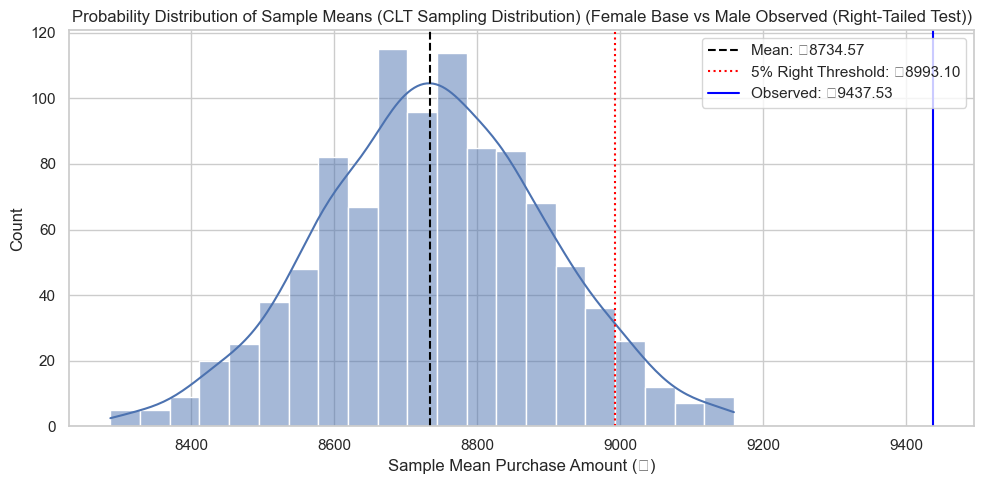

--- HYPOTHESIS TEST: TWO-SAMPLE T-TEST (Marital Status vs. Purchase) ---
T-statistic: -0.3438
P-value:     7.3100e-01
Result: Fail to reject H0 — No statistically significant difference in spending.
--- HYPOTHESIS TEST: ONE-WAY ANOVA (Age Groups vs. Purchase) ---
F-statistic: 40.5758
P-value:     1.0536e-49
Result: Reject H0 — At least one Age group has a significantly different mean purchase amount.
95% Parametric CIs by Age Group:
  Age 0-17: ₹8852 - ₹9015  (Mean: ₹8933, n=15102)
  Age 18-25: ₹9138 - ₹9201  (Mean: ₹9170, n=99660)
  Age 26-35: ₹9232 - ₹9274  (Mean: ₹9253, n=219587)
  Age 36-45: ₹9302 - ₹9361  (Mean: ₹9331, n=110013)
  Age 46-50: ₹9163 - ₹9254  (Mean: ₹9209, n=45701)
  Age 51-55: ₹9484 - ₹9586  (Mean: ₹9535, n=38501)
  Age 55+: ₹9269 - ₹9403  (Mean: ₹9336, n=21504)


In [53]:
"""
We use hypothesis tests to verify the CIs we found are actually statistically significant.
"""

def get_parametric_ci(data, confidence=0.95):
    # Calculates standard t-distribution Confidence Interval for mean.
    n = len(data)
    mean = np.mean(data)
    se = stats.sem(data)
    margin = se * stats.t.ppf((1 + confidence) / 2, df=n - 1)
    return mean, mean - margin, mean + margin, se

# ---------------------------------------------------------
# 1. Descriptive Stats & Parametric Confidence Intervals
# ---------------------------------------------------------

female = df[df['Gender'] == 'F']['Purchase'].values
male = df[df['Gender'] == 'M']['Purchase'].values

print('--- OVERALL OBSERVED METRICS ---')
print(f'Female Mean: ₹{female.mean():.2f}')
print(f'Male Mean:   ₹{male.mean():.2f}')
print(f'Difference:  ₹{male.mean() - female.mean():.2f}')

print('--- PARAMETRIC CONFIDENCE INTERVALS (GENDER) ---')
for level in [0.90, 0.95, 0.99]:
    f_mean, f_low, f_high, f_se = get_parametric_ci(female, level)
    m_mean, m_low, m_high, m_se = get_parametric_ci(male, level)
    
    overlap = not (f_high < m_low or m_high < f_low)
    
    print(f"{int(level*100)}% Confidence Interval:")
    print(f"  Female: ₹{f_low:.2f} - ₹{f_high:.2f}  (SE: ₹{f_se:.2f})")
    print(f"  Male:   ₹{m_low:.2f} - ₹{m_high:.2f}  (SE: ₹{m_se:.2f})")
    print(f"  CIs Overlap? {overlap}")

# ---------------------------------------------------------
# 2. Hypothesis Test: Two-Sample Independent T-Test (Gender)
# ---------------------------------------------------------

print('--- HYPOTHESIS TEST: TWO-SAMPLE T-TEST (Gender vs. Purchase) ---')
# Check variance homogeneity via Welch's t-test (equal_var=False)
t_stat, p_val_gender = stats.ttest_ind(male, female, equal_var=False)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value:     {p_val_gender:.4e}")
if p_val_gender < 0.05:
    print("Result: Reject H0 — Significant difference in spending between Male and Female groups.")
else:
    print("Result: Fail to reject H0 — No statistically significant difference in spending.")

# CLT Plot overlay: Right-tailed test showing Female Null vs Male Observed
f_means_clt = clt_sample_means(female, sample_size=1000, n_samples=1000)
f_se_clt = np.std(f_means_clt, ddof=1)
show_ci_plot(f_means_clt, female.mean(), f_se_clt, observed_val=male.mean(), side="right", title_suffix="Female Base vs Male Observed (Right-Tailed Test)")

# ---------------------------------------------------------
# 3. Hypothesis Test: Two-Sample Independent T-Test (Marital Status)
# ---------------------------------------------------------

print('--- HYPOTHESIS TEST: TWO-SAMPLE T-TEST (Marital Status vs. Purchase) ---')
married = df[df['Marital_Status'] == 1]['Purchase'].values
unmarried = df[df['Marital_Status'] == 0]['Purchase'].values

t_stat_m, p_val_m = stats.ttest_ind(married, unmarried, equal_var=False)

print(f"T-statistic: {t_stat_m:.4f}")
print(f"P-value:     {p_val_m:.4e}")
if p_val_m < 0.05:
    print("Result: Reject H0 — Significant difference in spending between Married and Unmarried groups.")
else:
    print("Result: Fail to reject H0 — No statistically significant difference in spending.")

# ---------------------------------------------------------
# 4. Hypothesis Test: One-Way ANOVA (Age Groups)
# ---------------------------------------------------------

print('--- HYPOTHESIS TEST: ONE-WAY ANOVA (Age Groups vs. Purchase) ---')
age_groups = np.sort(df["Age"].unique())
age_data_list = [df[df['Age'] == age]['Purchase'].values for age in age_groups]

# One-Way ANOVA Test across all age categories
f_stat, p_val_age = stats.f_oneway(*age_data_list)

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value:     {p_val_age:.4e}")
if p_val_age < 0.05:
    print("Result: Reject H0 — At least one Age group has a significantly different mean purchase amount.")
else:
    print("Result: Fail to reject H0 — No significant difference across Age groups.")

print('95% Parametric CIs by Age Group:')
for age, data in zip(age_groups, age_data_list):
    mean, low, high, _ = get_parametric_ci(data, 0.95)
    print(f"  Age {age}: ₹{low:.0f} - ₹{high:.0f}  (Mean: ₹{mean:.0f}, n={len(data)})")

## VERIFY TESTS
Verification Phase. Which specific groups drive that difference?

One-Way ANOVA Result: F = 40.5758, p-value = 1.0536e-49

--- TUKEY HSD PAIRWISE COMPARISONS ---
  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj    lower    upper   reject
--------------------------------------------------------
  0-17  18-25   236.199    0.0  106.9071 365.4908   True
  0-17  26-35   319.226    0.0  194.6669 443.7851   True
  0-17  36-45  397.8861    0.0  269.3973 526.3748   True
  0-17  46-50  275.1611    0.0  136.1875 414.1346   True
  0-17  51-55  601.3434    0.0  459.1789 743.5079   True
  0-17    55+  402.8158    0.0  245.6171 560.0145   True
 18-25  26-35    83.027 0.0003   26.4748 139.5792   True
 18-25  36-45  161.6871    0.0   96.9373 226.4369   True
 18-25  46-50   38.9621 0.8162  -44.6849 122.6091  False
 18-25  51-55  365.1444    0.0  276.2968 453.9921   True
 18-25    55+  166.6169 0.0002   55.2858 277.9479   True
 26-35  36-45   78.6601 0.0004   23.9688 133.3513   True
 26-35  46-50  -44.0649 0.6116 -120.1926  32.0627

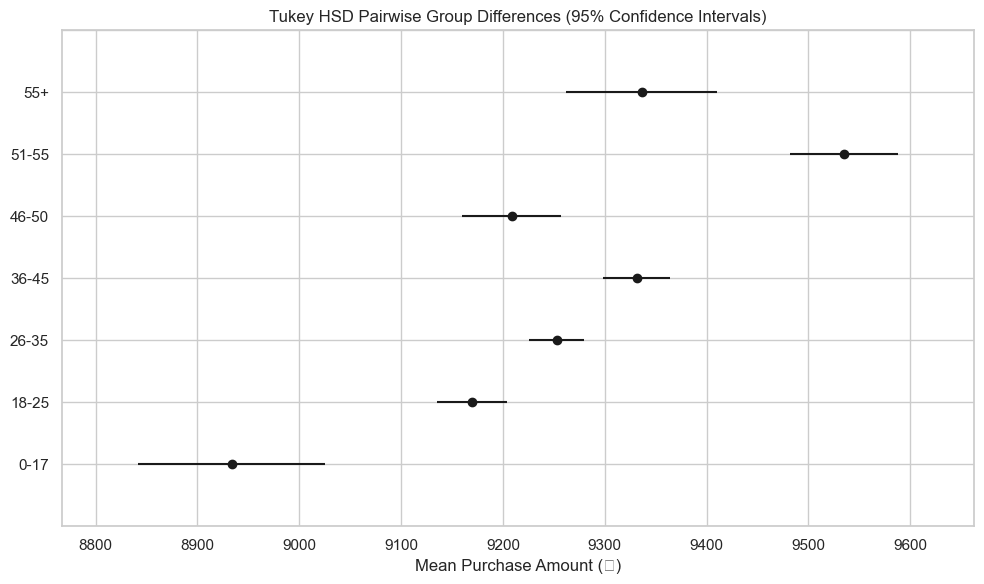

In [12]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 1. Run One-Way ANOVA First (Prerequisite)
age_groups = np.sort(df["Age"].unique())
age_data_list = [df[df['Age'] == age]['Purchase'].values for age in age_groups]

f_stat, p_val_anova = stats.f_oneway(*age_data_list)
print(f"One-Way ANOVA Result: F = {f_stat:.4f}, p-value = {p_val_anova:.4e}\n")

# 2. Perform Post-Hoc Tukey HSD Test
tukey_result = pairwise_tukeyhsd(
    endog=df['Purchase'],   # Quantitative response variable
    groups=df['Age'],       # Categorical grouping variable
    alpha=0.05              # Significance level (95% confidence)
)

# 3. Display Detailed Pairwise Comparison Table
print("--- TUKEY HSD PAIRWISE COMPARISONS ---")
print(tukey_result)

# 4. Filter and Print Only Statistically Significant Differences
tukey_df = pd.DataFrame(
    data=tukey_result._results_table.data[1:], 
    columns=tukey_result._results_table.data[0]
)

sig_differences = tukey_df[tukey_df['reject'] == True]

print(f"\n--- SIGNIFICANT PAIRS ({len(sig_differences)} found) ---")
for _, row in sig_differences.iterrows():
    print(f"Age Group {row['group1']} vs {row['group2']}: Mean Diff = ₹{row['meandiff']:.2f}, p-adj = {row['p-adj']:.4f}")

# 5. Visualize the Pairwise Confidence Intervals
fig, ax = plt.subplots(figsize=(10, 6))
tukey_result.plot_simultaneous(ax=ax, xlabel="Mean Purchase Amount (₹)")
ax.set_title("Tukey HSD Pairwise Group Differences (95% Confidence Intervals)")
plt.tight_layout()
plt.show()

## CHART SET

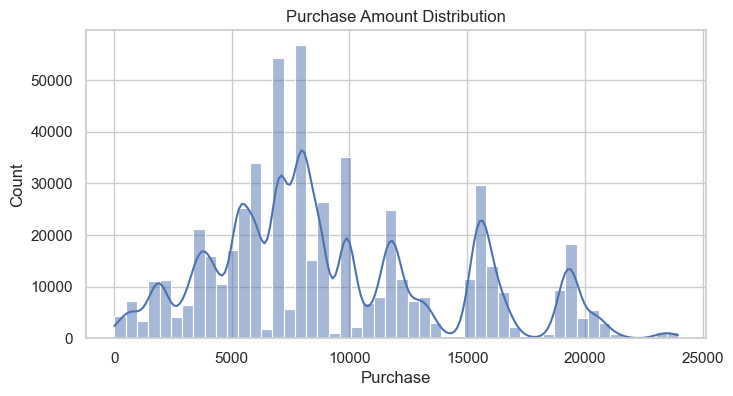

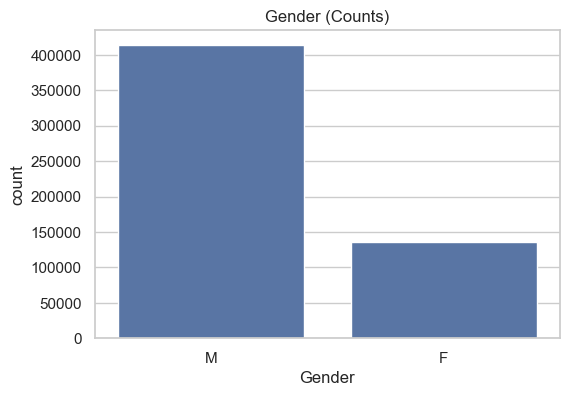

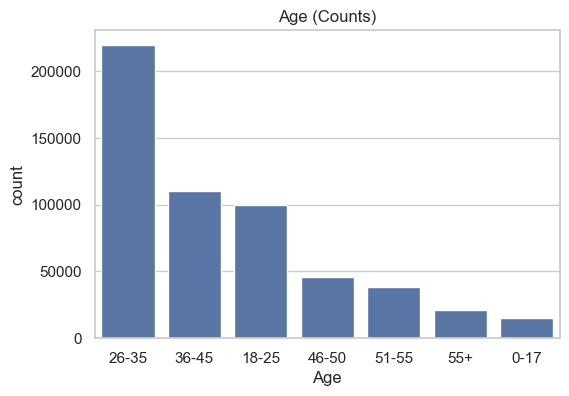

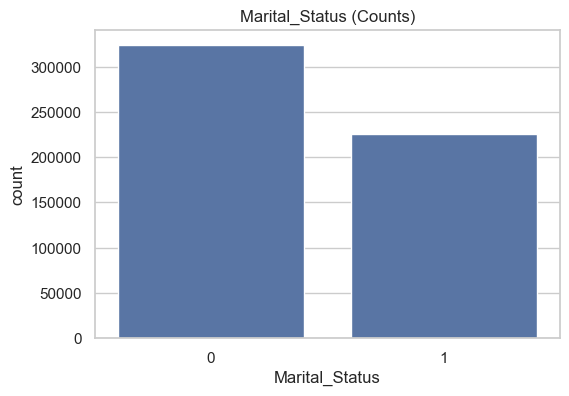

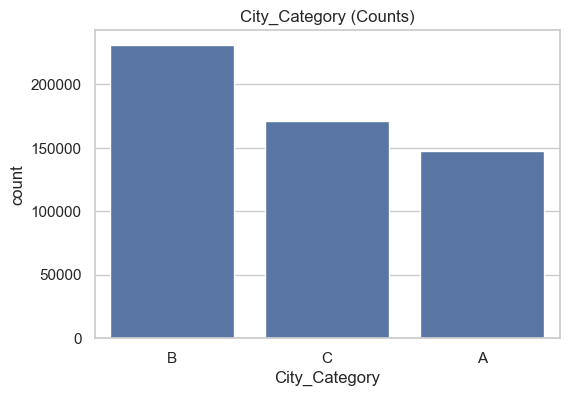

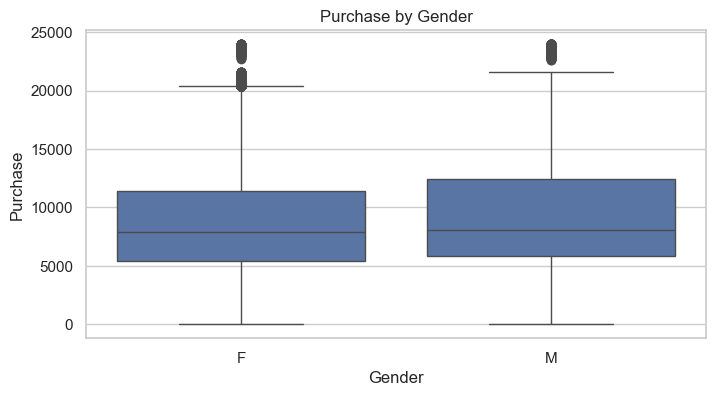

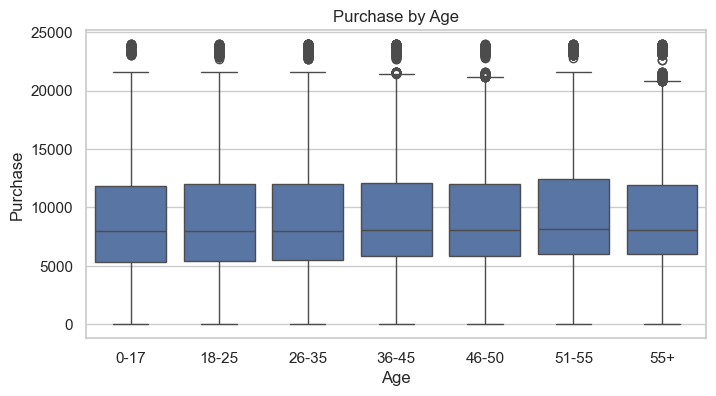

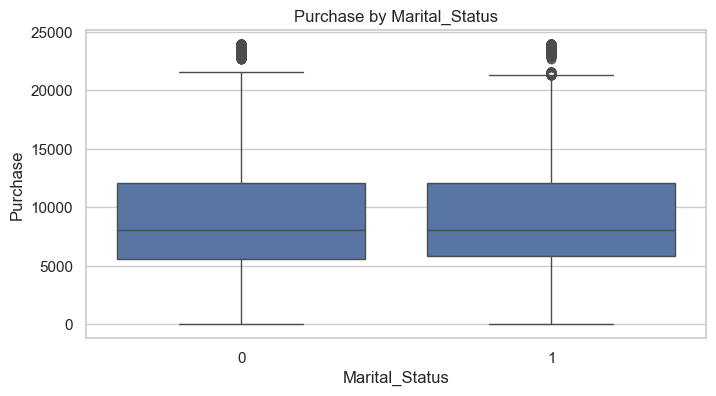

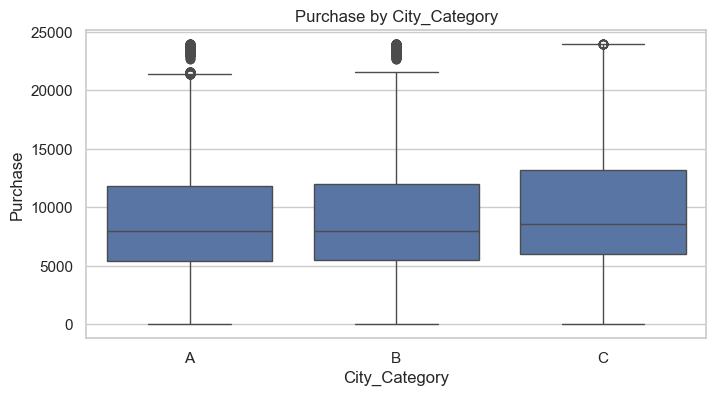

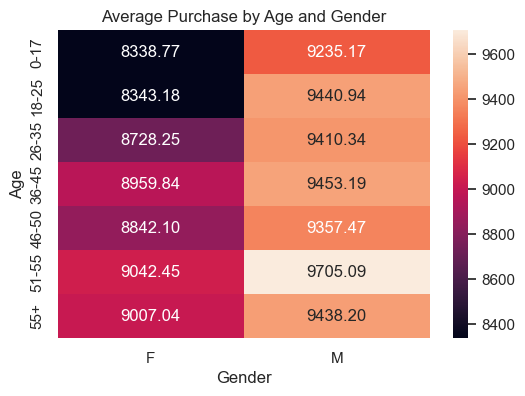

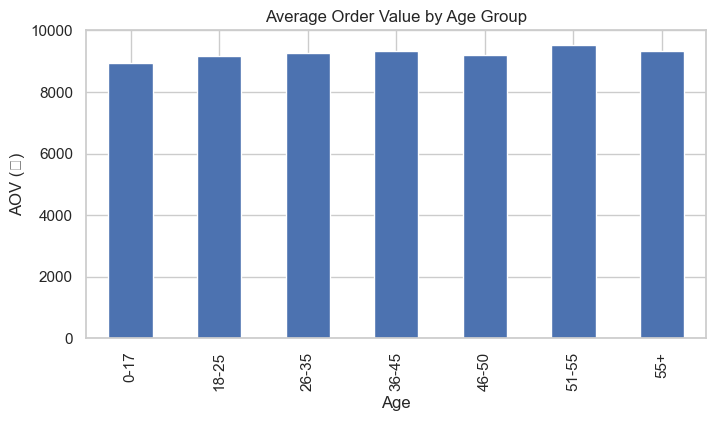

In [13]:
age_order = df["Age"].unique().sort_values()

# Univariate: purchase distribution
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df['Purchase'], bins=50, kde=True, ax=ax)
ax.set_title('Purchase Amount Distribution')
plt.show()

# Univariate: categorical counts
for col in ['Gender', 'Age', 'Marital_Status', 'City_Category']:
    fig, ax = plt.subplots(figsize=(6, 4))
    order = df[col].value_counts().index # sorted bars desc
    sns.countplot(data=df, x=col, order=order, ax=ax)
    ax.set_title(f'{col} (Counts)')
    plt.show()

# Bivariate: purchase by segments
for col in ['Gender', 'Age', 'Marital_Status', 'City_Category']:
    fig, ax = plt.subplots(figsize=(8, 4))
    order = age_order if col == 'Age' else None
    sns.boxplot(data=df, x=col, y='Purchase', order=order, ax=ax)
    ax.set_title(f'Purchase by {col}')
    plt.show()

# Mean purchase heatmap by Age and Gender (business-focused)
pivot_age_gender = df.pivot_table(values='Purchase', index='Age', columns='Gender', aggfunc='mean')
pivot_age_gender = pivot_age_gender.reindex(age_order)
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(pivot_age_gender, annot=True, fmt='.2f', ax=ax)
ax.set_title('Average Purchase by Age and Gender')
plt.show()

# AOV by age group
aov_age = df.groupby('Age', observed=False)['Purchase'].mean().reindex(age_order)
fig, ax = plt.subplots(figsize=(8, 4))
aov_age.plot(kind='bar', ax=ax)
ax.set_title('Average Order Value by Age Group')
ax.set_ylabel('AOV (₹)')
plt.show()

## CUSTOMER PROFILE TABLE (SEGMENT-WISE)

In [14]:
profile_gender = df.groupby('Gender', observed=False).agg(
    Transactions=('Purchase', 'size'),
    UniqueCustomers=('User_ID', 'nunique'),
    AOV=('Purchase', 'mean'),
    Purchase_median=('Purchase', 'median'),
    TopAge=('Age', lambda x: x.mode().iloc[0] if not x.mode().empty else None),
    TopCity=('City_Category', lambda x: x.mode().iloc[0] if not x.mode().empty else None),
    MarriedPct=('Marital_Status', lambda x: (x.astype(int) == 1).sum()/len(x))
).reindex(['F', 'M'])
print('\nCustomer profile by Gender:')
display(profile_gender.round(2))

profile_age = df.groupby('Age', observed=False).agg(
    Transactions=('Purchase', 'size'),
    UniqueCustomers=('User_ID', 'nunique'),
    AOV=('Purchase', 'mean'),
    Purchase_median=('Purchase', 'median'),
    FemalePct=('Gender', lambda x: (x == 'F').sum()/len(x)),
    MarriedPct=('Marital_Status', lambda x: (x.astype(int) == 1).sum()/len(x))
).reindex(age_order)
print('\nCustomer profile by Age group:')
display(profile_age.round(2))


Customer profile by Gender:


,Transactions,UniqueCustomers,AOV,Purchase_median,TopAge,TopCity,MarriedPct
Gender,,,,,,,
F,135809,1666,8734.57,7914.0,26-35,B,0.42
M,414259,4225,9437.53,8098.0,26-35,B,0.41



Customer profile by Age group:


,Transactions,UniqueCustomers,AOV,Purchase_median,FemalePct,MarriedPct
Age,,,,,,
0-17,15102,218,8933.46,7986.0,0.34,0.00
18-25,99660,1069,9169.66,8027.0,0.25,0.21
26-35,219587,2053,9252.69,8030.0,0.23,0.39
36-45,110013,1167,9331.35,8061.0,0.25,0.40
46-50,45701,531,9208.63,8036.0,0.29,0.72
51-55,38501,481,9534.81,8130.0,0.26,0.72
55+,21504,372,9336.28,8105.5,0.24,0.63


## MONEY-FOCUSED SEGMENT KPIs

In [15]:
segments = ['Gender', 'Age', 'Marital_Status', 'City_Category', 'Product_Category']
for seg in segments:
    print(f"\n{seg} - Revenue KPIs")
    display(money_segment(seg).round(2))


Gender - Revenue KPIs


,transactions,unique_customers,AOV,revenue,revenue_share
Gender,,,,,
M,414259,4225,9437.53,3909580100,0.77
F,135809,1666,8734.57,1186232642,0.23



Age - Revenue KPIs


,transactions,unique_customers,AOV,revenue,revenue_share
Age,,,,,
26-35,219587,2053,9252.69,2031770578,0.40
36-45,110013,1167,9331.35,1026569884,0.20
18-25,99660,1069,9169.66,913848675,0.18
46-50,45701,531,9208.63,420843403,0.08
51-55,38501,481,9534.81,367099644,0.07
55+,21504,372,9336.28,200767375,0.04
0-17,15102,218,8933.46,134913183,0.03



Marital_Status - Revenue KPIs


,transactions,unique_customers,AOV,revenue,revenue_share
Marital_Status,,,,,
0,324731,3417,9265.91,3008927447,0.59
1,225337,2474,9261.17,2086885295,0.41



City_Category - Revenue KPIs


,transactions,unique_customers,AOV,revenue,revenue_share
City_Category,,,,,
B,231173,1707,9151.30,2115533605,0.42
C,171175,3139,9719.92,1663807476,0.33
A,147720,1045,8911.94,1316471661,0.26



Product_Category - Revenue KPIs


,transactions,unique_customers,AOV,revenue,revenue_share
Product_Category,,,,,
1,140378,5767,13606.22,1910013754,0.37
5,150933,5751,6240.09,941835229,0.18
8,113925,5659,7498.96,854318799,0.17
6,20466,4085,15838.48,324150302,0.06
2,23864,4296,11251.94,268516186,0.05
3,20213,3838,10096.71,204084713,0.04
16,9828,3130,14766.04,145120612,0.03
11,24287,3583,4685.27,113791115,0.02
10,5125,2328,19675.57,100837301,0.02


## KEY BUSINESS ANSWERS

In [16]:
print('\nKey probability answers:')
print('P(Premium Spend | Male)   =', round(float(p_row_given_col_map['Gender'].loc['premium', 'M']), 4))
print('P(Premium Spend | Female) =', round(float(p_row_given_col_map['Gender'].loc['premium', 'F']), 4))
print('P(Premium Spend | Married)    =', round(float(p_row_given_col_map['Marital_Status'].loc['premium', 1]), 4))
print('P(Premium Spend | Unmarried)  =', round(float(p_row_given_col_map['Marital_Status'].loc['premium', 0]), 4))

print('\nKey money answers:')
print('Top AOV by Gender:', df.groupby('Gender', observed=False)['Purchase'].mean().round(2).to_dict())
print('Top AOV by Age:', df.groupby('Age', observed=False)['Purchase'].mean().round(2).sort_values(ascending=False).to_dict())
print('Top revenue city:', money_segment('City_Category').index[0])
print('Top revenue product category:', money_segment('Product_Category').index[0])


Key probability answers:
P(Premium Spend | Male)   = 0.265
P(Premium Spend | Female) = 0.205
P(Premium Spend | Married)    = 0.249
P(Premium Spend | Unmarried)  = 0.251

Key money answers:
Top AOV by Gender: {'F': 8734.57, 'M': 9437.53}
Top AOV by Age: {'51-55': 9534.81, '55+': 9336.28, '36-45': 9331.35, '26-35': 9252.69, '46-50': 9208.63, '18-25': 9169.66, '0-17': 8933.46}
Top revenue city: B
Top revenue product category: 1


# CONCLUSION

### Executive Summary
This Black Friday sample confirms that male customers spend more per transaction than female customers, and the 95% confidence intervals do not overlap, so the difference is statistically meaningful. The largest value comes from the 26-35 and 36-45 age groups, while marital status and city category show smaller differences. Product categories are highly skewed, meaning some categories drive a disproportionate share of revenue.

### What the probabilities say
- `P(Premium Spend | Male)` is materially higher than `P(Premium Spend | Female)`, so gender is a strong routing signal for premium offers.
- `P(Premium Spend | Married)` is almost the same as `P(Premium Spend | Unmarried)`, so marital status should not be used as a targeting lever.
- High spend is concentrated in a few age brackets and city categories, giving Walmart clear segments to prioritize.

### Recommendations
1. **Prioritize male-led premium campaigns.** Use the gender confidence interval gap to justify higher investment in male-targeted Black Friday and high-ticket product ads.
2. **Target the 26-50 age bracket.** This group shows the highest AOV and revenue contribution; tailor creative and inventory to their preferences.
3. **Stop over-investing on marital status.** It does not differentiate spend; redirect that budget to gender and age signals.
4. **Use the CLT intervals for budget sizing.** The 95% CIs give a reliable range for expected average spend per segment; set ROI thresholds and daily spend caps around the lower bound of the interval to protect margin.
5. **Focus product mix on the top revenue categories.** Move inventory and promotional visibility toward the categories that already produce the most revenue per transaction.
6. **Run a two-question qualifier at checkout/online:** "Gender + Age group" can estimate expected spend and trigger personalized upsell recommendations.

### Limitations
The analysis is based on one Black Friday sample and assumes spend patterns are stable. Purchase amount is the only revenue proxy; margin and profitability are not included. Confidence intervals are sample-based and should be refreshed with new data.